<a href="https://colab.research.google.com/github/omerbibin/pneumonia-detection-cxr/blob/main/Week06_Deep_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
#  WEEK 6 — CELL 1: IMPORTS + HIGH-SPEED ZIP EXTRACTION
# ============================================================
import os, sys, gc, json, time, shutil, zipfile, warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style("whitegrid")

import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# --- Mount Drive (idempotent) ---
from google.colab import drive
drive.mount('/content/drive')

# --- Canonical paths ---
PROJECT_ROOT   = Path("/content/drive/MyDrive/PneumoniaDetection")
MANIFEST_PATH  = PROJECT_ROOT / "reports"  / "manifest.csv"
MODELS_DIR     = PROJECT_ROOT / "models"
FIGURES_DIR    = PROJECT_ROOT / "reports"  / "figures"
HISTORY_DIR    = PROJECT_ROOT / "reports"  / "history"
for d in (MODELS_DIR, FIGURES_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)

DRIVE_ZIP_PATH = PROJECT_ROOT / "data" / "raw" / "chest_xray.zip"
DRIVE_UNZIP    = PROJECT_ROOT / "data" / "raw" / "chest_xray"   # existing from Week 2
LOCAL_ZIP      = Path("/content/chest_xray.zip")
LOCAL_DATA     = Path("/content/chest_xray")

# --- GPU sanity ---
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU available: {bool(gpus)}  {gpus[0].name if gpus else ''}")
assert gpus, "Enable T4 GPU: Runtime → Change runtime type → T4 GPU, then re-run."

# ── FAST-PATH STORAGE RECOVERY ─────────────────────────────────────
# Strategy hierarchy (first match wins):
#   1. Local extracted data already present from this runtime  → done
#   2. Local zip cached on /content                            → extract only
#   3. Drive zip exists                                        → copy + extract (FAST PATH)
#   4. Drive unzipped folder exists (no zip)                   → create zip on Drive once,
#                                                                 then copy + extract
# ───────────────────────────────────────────────────────────────────

t_total = time.time()

if LOCAL_DATA.exists() and (LOCAL_DATA / "train").exists():
    print("✓ Local data already extracted — skipping I/O.")

elif LOCAL_ZIP.exists():
    print(f"Found cached ZIP at {LOCAL_ZIP} — extracting locally...")
    t0 = time.time()
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall("/content")
    print(f"  Extract: {time.time()-t0:.1f}s")

elif DRIVE_ZIP_PATH.exists():
    print(f"ZIP found on Drive ({DRIVE_ZIP_PATH.stat().st_size/(1024**3):.2f} GB).")
    t0 = time.time()
    shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP)
    print(f"  Copy Drive→local: {time.time()-t0:.1f}s")
    t0 = time.time()
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall("/content")
    print(f"  Extract:          {time.time()-t0:.1f}s")

else:
    # One-time bootstrap: zip currently doesn't exist on Drive, but folder does.
    # We create the zip ON LOCAL DISK from the Drive folder (one slow scan),
    # then upload the single zip to Drive so all future sessions use the fast path.
    assert DRIVE_UNZIP.exists(), (
        f"Neither {DRIVE_ZIP_PATH} nor {DRIVE_UNZIP} exists on Drive. "
        "Re-run Week 2 acquisition first."
    )
    print(f"⚠ One-time bootstrap: creating {DRIVE_ZIP_PATH.name} from Drive folder.")
    print(f"  This single slow scan (~5-8 min) eliminates ALL future Drive I/O.")
    t0 = time.time()
    # Step A: zip directly to local SSD (avoids writing many-small-files-to-Drive issue)
    local_temp_zip = "/content/chest_xray_temp"   # base name; .zip appended by make_archive
    shutil.make_archive(
        base_name = local_temp_zip,
        format    = "zip",
        root_dir  = str(DRIVE_UNZIP.parent),
        base_dir  = DRIVE_UNZIP.name,
    )
    shutil.move(local_temp_zip + ".zip", LOCAL_ZIP)
    print(f"  Created local zip: {time.time()-t0:.1f}s "
          f"({LOCAL_ZIP.stat().st_size/(1024**3):.2f} GB)")

    # Step B: upload zip to Drive (single large file = fast write)
    t0 = time.time()
    shutil.copy(LOCAL_ZIP, DRIVE_ZIP_PATH)
    print(f"  Uploaded to Drive: {time.time()-t0:.1f}s")

    # Step C: extract locally
    t0 = time.time()
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall("/content")
    print(f"  Extract:           {time.time()-t0:.1f}s")

print(f"\n✓ Storage recovery complete in {time.time()-t_total:.1f}s total.")
print(f"  Local data: {LOCAL_DATA}")

# --- Verification ---
n_train = sum(1 for _ in (LOCAL_DATA / "train" / "NORMAL").glob("*.jpeg"))
n_train += sum(1 for _ in (LOCAL_DATA / "train" / "PNEUMONIA").glob("*.jpeg"))
print(f"  Train images discovered: {n_train}  (expected: 5,216 in original layout)")

Mounted at /content/drive
GPU available: True  /physical_device:GPU:0
⚠ One-time bootstrap: creating chest_xray.zip from Drive folder.
  This single slow scan (~5-8 min) eliminates ALL future Drive I/O.
  Created local zip: 1110.9s (2.29 GB)
  Uploaded to Drive: 23.0s
  Extract:           31.7s

✓ Storage recovery complete in 1165.9s total.
  Local data: /content/chest_xray
  Train images discovered: 5216  (expected: 5,216 in original layout)


In [5]:
# ============================================================
#  WEEK 6 — CELL 2: HIGH-PERFORMANCE tf.data PIPELINE
# ============================================================
import psutil

# --- Fixed hyperparameters (controlled vs Week 5) ---
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# --- Reload manifest (single source of truth from Week 3) ---
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Manifest: {len(manifest)} rows  |  splits: {manifest['split'].unique().tolist()}")

# --- Memory preflight: ensure RAM cache fits ---
available_gb  = psutil.virtual_memory().available / (1024**3)
n_train_imgs  = (manifest["split"] == "train_split").sum()
cache_size_gb = n_train_imgs * 224 * 224 * 3 * 4 / (1024**3)
print(f"\nMemory preflight:")
print(f"  Available RAM   : {available_gb:.1f} GB")
print(f"  Train cache size: {cache_size_gb:.2f} GB  ({n_train_imgs} float32 tensors)")
assert available_gb > cache_size_gb + 1.5, "Insufficient RAM for full cache."
print("  ✓ RAM check passed.")

# --- Preprocessing fn (note: augmentation lives inside the MODEL, not here) ---
def _load_and_normalize(path: tf.Tensor, label: tf.Tensor):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)         # 3-channel for pretrained compatibility
    img = tf.image.resize(img, IMG_SIZE)                 # bilinear to 224×224
    img = tf.cast(img, tf.float32) / 255.0              # normalize to [0, 1]
    return img, label

# --- The critical pipeline ordering ---
def make_fast_dataset(split_name: str, shuffle: bool) -> tf.data.Dataset:
    """
    Pipeline order (each step is load-bearing):
        from_tensor_slices  → in-memory path/label arrays
        map(load+normalize) → parallel CPU decode
        cache()             → *** RAM CACHE: epoch 1 reads disk, epochs 2+ read RAM ***
        shuffle             → shuffle the cached tensors (only if training)
        batch               → group into GPU-ready batches
        prefetch(AUTOTUNE)  → overlap CPU prep with GPU compute
    """
    sub    = manifest[manifest["split"] == split_name]
    paths  = sub["filepath"].values
    labels = (sub["class"] == "PNEUMONIA").astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_load_and_normalize, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                                              # ★ keystone optimization
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=RANDOM_SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

# --- Build all splits ---
train_ds = make_fast_dataset("train_split", shuffle=True)
val_ds   = make_fast_dataset("val_split",   shuffle=False)
test_ds  = make_fast_dataset("test",        shuffle=False)

# --- Warm the cache + measure speedup ---
print("\nWarming cache (epoch-1 disk read, then epoch-2 RAM read for benchmarking)...")
t0 = time.time(); _ = [None for _ in train_ds]; t1 = time.time() - t0
t0 = time.time(); _ = [None for _ in train_ds]; t2 = time.time() - t0
print(f"  Epoch-1 scan (disk+decode+cache fill): {t1:.1f}s")
print(f"  Epoch-2 scan (RAM-only):               {t2:.1f}s")
print(f"  Speed-up after caching:                {t1/max(t2,0.01):.1f}×")

# --- Class weights inherited from Week 5 ---
CLASS_WEIGHTS = {0: 1.9464, 1: 0.6728}
print(f"\nClass weights (from Week 5): {CLASS_WEIGHTS}")

Manifest: 5856 rows  |  splits: ['train_split', 'val_split', 'val_original', 'test']

Memory preflight:
  Available RAM   : 10.3 GB
  Train cache size: 2.65 GB  (4722 float32 tensors)
  ✓ RAM check passed.

Warming cache (epoch-1 disk read, then epoch-2 RAM read for benchmarking)...
  Epoch-1 scan (disk+decode+cache fill): 35.4s
  Epoch-2 scan (RAM-only):               1.3s
  Speed-up after caching:                27.8×

Class weights (from Week 5): {0: 1.9464, 1: 0.6728}


CosineDecay configured:
  initial_learning_rate : 1e-04
  floor (α × init)      : 1e-06
  decay_steps           : 2,960  (148 batches × 20 epochs)


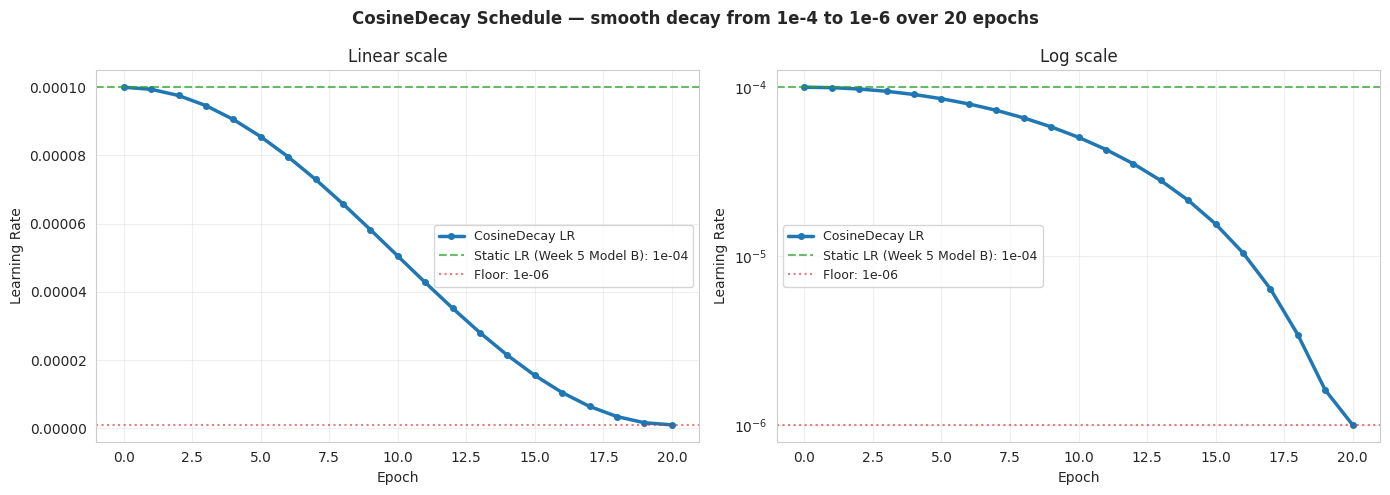


Key-epoch LR values:
  Epoch   0: 1.000e-04
  Epoch   3: 9.460e-05
  Epoch   5: 8.550e-05
  Epoch  10: 5.050e-05
  Epoch  15: 1.550e-05
  Epoch  20: 1.000e-06


In [6]:
# ============================================================
#  WEEK 6 — CELL 3: COSINE DECAY LR SCHEDULE
# ============================================================

# --- Schedule parameters ---
INITIAL_LR = 1e-4   # same starting LR as Model B for controlled comparison
FINAL_LR   = 1e-6   # decay floor = 1% of initial
N_EPOCHS   = 20
ALPHA      = FINAL_LR / INITIAL_LR

N_BATCHES_PER_EPOCH = len(train_ds)
TOTAL_DECAY_STEPS   = N_BATCHES_PER_EPOCH * N_EPOCHS

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = INITIAL_LR,
    decay_steps           = TOTAL_DECAY_STEPS,
    alpha                 = ALPHA,
)

print(f"CosineDecay configured:")
print(f"  initial_learning_rate : {INITIAL_LR:.0e}")
print(f"  floor (α × init)      : {INITIAL_LR * ALPHA:.0e}")
print(f"  decay_steps           : {TOTAL_DECAY_STEPS:,}  "
      f"({N_BATCHES_PER_EPOCH} batches × {N_EPOCHS} epochs)")

# --- Visualization ---
epochs_axis = list(range(N_EPOCHS + 1))
lr_values   = [float(cosine_schedule(N_BATCHES_PER_EPOCH * e)) for e in epochs_axis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CosineDecay Schedule — smooth decay from 1e-4 to 1e-6 over 20 epochs",
             fontsize=12, weight="bold")

for ax, scale, label in [(ax1, "linear", "Linear scale"), (ax2, "log", "Log scale")]:
    ax.plot(epochs_axis, lr_values, linewidth=2.5, marker="o", markersize=4,
            color="#1f77b4", label="CosineDecay LR")
    ax.axhline(INITIAL_LR, linestyle="--", color="#2ca02c", alpha=0.7,
               label=f"Static LR (Week 5 Model B): {INITIAL_LR:.0e}")
    ax.axhline(FINAL_LR,   linestyle=":",  color="#d62728", alpha=0.6,
               label=f"Floor: {FINAL_LR:.0e}")
    if scale == "log":
        ax.set_yscale("log")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Learning Rate")
    ax.set_title(label); ax.grid(alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig07_lr_schedule.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey-epoch LR values:")
for e in [0, 3, 5, 10, 15, 20]:
    print(f"  Epoch {e:>3}: {cosine_schedule(N_BATCHES_PER_EPOCH * e).numpy():.3e}")

In [7]:
# ============================================================
#  WEEK 6 — CELL 4: DEEP CNN ARCHITECTURE (VGG-Deep 5-Block)
# ============================================================
#  Spatial: 224 → 112 → 56 → 28 → 14 → 7  (five MaxPool(2) halvings)
#  Channels: 32 → 64 → 128 → 256 → 512
#  Head:    GAP → Dense(128) → Dropout(0.5) → Dense(1, sigmoid)
#  Inherited from Week 5 Model B:
#    ✓ Augmentation (no vertical flip)
#    ✓ L2(1e-4) on all Conv + Dense kernels
#    ✓ BatchNorm after every Conv, use_bias=False
# ============================================================

# --- Augmentation block (identical to Week 5 — medically validated) ---
augmentation_layer = Sequential([
    layers.RandomFlip("horizontal"),                                # ✓ valid for AP CXR
    layers.RandomRotation(0.05, fill_mode="constant", fill_value=0.0),     # ±18°
    layers.RandomZoom(0.10, 0.10, fill_mode="constant", fill_value=0.0),   # ±10%
    layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=0.0),  # ±5%
    # NOTE: vertical flip intentionally excluded — inverted CXR is non-clinical
], name="augmentation")


def build_deep_cnn(
    channel_progression : list = [32, 64, 128, 256, 512],
    dense_units         : int  = 128,
    dropout_rate        : float= 0.50,
    l2_reg              : float= 1e-4,
    learning_rate              = None,
    name                : str  = "DeepCNN_5Block",
) -> tf.keras.Model:
    """5-block VGG-Deep CNN with GAP head, augmentation, L2, BN."""
    reg = regularizers.l2(l2_reg)
    lr  = learning_rate if learning_rate is not None else 1e-4

    model_layers = [augmentation_layer]   # GPU-side augmentation (auto-disabled in eval)

    for i, n_filters in enumerate(channel_progression, start=1):
        model_layers += [
            layers.Conv2D(
                filters     = n_filters,
                kernel_size = 3,
                padding     = "same",
                use_bias    = False,                # BN's beta replaces the bias
                kernel_regularizer = reg,
                name        = f"block{i}_conv",
            ),
            layers.BatchNormalization(name=f"block{i}_bn"),
            layers.Activation("relu", name=f"block{i}_relu"),
            layers.MaxPooling2D(pool_size=2, name=f"block{i}_pool"),
        ]

    # GAP collapses 7×7×512 → 512 by spatial average; avoids 6.4M params that
    # a naive Flatten + Dense head would require.
    model_layers += [
        layers.GlobalAveragePooling2D(name="gap"),
        layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=reg, name="head_dense"),
        layers.Dropout(dropout_rate, name="head_dropout"),
        layers.Dense(1, activation="sigmoid", name="output"),
    ]

    model = Sequential(model_layers, name=name)
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
        loss      = "binary_crossentropy",
        metrics   = [
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc",    curve="ROC"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model

# --- Instantiate and inspect ---
deep_cnn = build_deep_cnn(
    learning_rate = cosine_schedule,
    name          = "DeepCNN_5Block_W6",
)
deep_cnn.build(input_shape=(None, 224, 224, 3))
deep_cnn.summary()

n_params = deep_cnn.count_params()
print(f"\nParameter context:")
print(f"  Model B (Week 5, 3 blocks)  : ~110,000 params")
print(f"  DeepCNN_5Block (this model)  : {n_params:,} params")
print(f"  Capacity ratio               : {n_params/110_000:.1f}× more")
print(f"  Note: GAP keeps head at {512*128+128+129:,} params; "
      f"a Flatten-equivalent would add ~{7*7*512*128:,}.")

Model: "DeepCNN_5Block_W6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv (Conv2D)            │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu (Activation)        │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu (Activation)        │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv (Conv2D)            │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu (Activation)        │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv (Conv2D)            │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_bn (BatchNormalization)  │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_relu (Activation)        │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv (Conv2D)            │ (None, 14, 14, 512)    │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_bn (BatchNormalization)  │ (None, 14, 14, 512)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_relu (Activation)        │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           12

 Total params: 1,637,345 (6.25 MB)

 Trainable params: 1,635,361 (6.24 MB)

 Non-trainable params: 1,984 (7.75 KB)


Parameter context:
  Model B (Week 5, 3 blocks)  : ~110,000 params
  DeepCNN_5Block (this model)  : 1,637,345 params
  Capacity ratio               : 14.9× more
  Note: GAP keeps head at 65,793 params; a Flatten-equivalent would add ~3,211,264.


In [8]:
# ============================================================
#  WEEK 6 — CELL 5: TRAINING EXECUTION
# ============================================================

CKPT_PATH = str(MODELS_DIR / "deep_cnn.keras")

callbacks_w6 = [
    EarlyStopping(
        monitor              = "val_auc",
        mode                 = "max",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1,
    ),
    ModelCheckpoint(
        filepath        = CKPT_PATH,
        monitor         = "val_auc",
        mode            = "max",
        save_best_only  = True,
        verbose         = 0,
    ),
    # Log the actual LR value from the cosine schedule into history
    tf.keras.callbacks.LambdaCallback(
        on_epoch_end = lambda epoch, logs: logs.update({
            "lr": float(cosine_schedule(deep_cnn.optimizer.iterations).numpy())
        })
    ),
]

print("═" * 62)
print(f"  Training DeepCNN_5Block_W6")
print(f"  LR        : CosineDecay  {INITIAL_LR:.0e} → {FINAL_LR:.0e}")
print(f"  Epochs    : up to {N_EPOCHS} (EarlyStopping patience=5 on val_auc)")
print(f"  Checkpoint: {CKPT_PATH}")
print(f"  Epoch 1 will be slower (cache fill); epochs 2+ are RAM-only.")
print("═" * 62)

t0 = time.time()
w6_history = deep_cnn.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = N_EPOCHS,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = callbacks_w6,
    verbose         = 1,
)
print(f"\nTotal training time: {(time.time()-t0)/60:.1f} min  "
      f"({len(w6_history.history['loss'])} epochs)")

# --- Persist history to Drive ---
hist_path = HISTORY_DIR / "deep_cnn_history.json"
with open(hist_path, "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in w6_history.history.items()},
              f, indent=2)
print(f"History saved: {hist_path}")

# --- Best-epoch summary ---
hist     = w6_history.history
best_idx = int(np.argmax(hist["val_auc"]))
print(f"\n{'─'*50}")
print(f"  Best epoch       : {best_idx + 1}")
print(f"  val_loss         : {hist['val_loss'][best_idx]:.4f}")
print(f"  val_accuracy     : {hist['val_accuracy'][best_idx]:.4f}")
print(f"  val_precision    : {hist['val_precision'][best_idx]:.4f}")
print(f"  val_recall       : {hist['val_recall'][best_idx]:.4f}  ← clinical headline")
print(f"  val_auc          : {hist['val_auc'][best_idx]:.4f}")
print(f"  val_pr_auc       : {hist['val_pr_auc'][best_idx]:.4f}")
print(f"  lr at best epoch : {hist['lr'][best_idx]:.2e}")
print(f"{'─'*50}")

══════════════════════════════════════════════════════════════
  Training DeepCNN_5Block_W6
  LR        : CosineDecay  1e-04 → 1e-06
  Epochs    : up to 20 (EarlyStopping patience=5 on val_auc)
  Checkpoint: /content/drive/MyDrive/PneumoniaDetection/models/deep_cnn.keras
  Epoch 1 will be slower (cache fill); epochs 2+ are RAM-only.
══════════════════════════════════════════════════════════════
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 37s 172ms/step - accuracy: 0.8528 - auc: 0.9257 - loss: 0.4243 - pr_auc: 0.9736 - precision: 0.9650 - recall: 0.8321 - val_accuracy: 0.7409 - val_auc: 0.5000 - val_loss: 1.9488 - val_pr_auc: 0.7409 - val_precision: 0.7409 - val_recall: 1.0000 - lr: 9.9391e-05
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.8863 - auc: 0.9594 - loss: 0.3373 - pr_auc: 0.9853 - precision: 0.9711 - recall: 0.8729 - val_accuracy: 0.7409 - val_auc: 0.5000 - val_loss: 2.0556 - val_pr_auc: 0.7409 - val_precision: 0.7409 - val_recall: 1.0000 - lr: 9.7577e-05
Ep

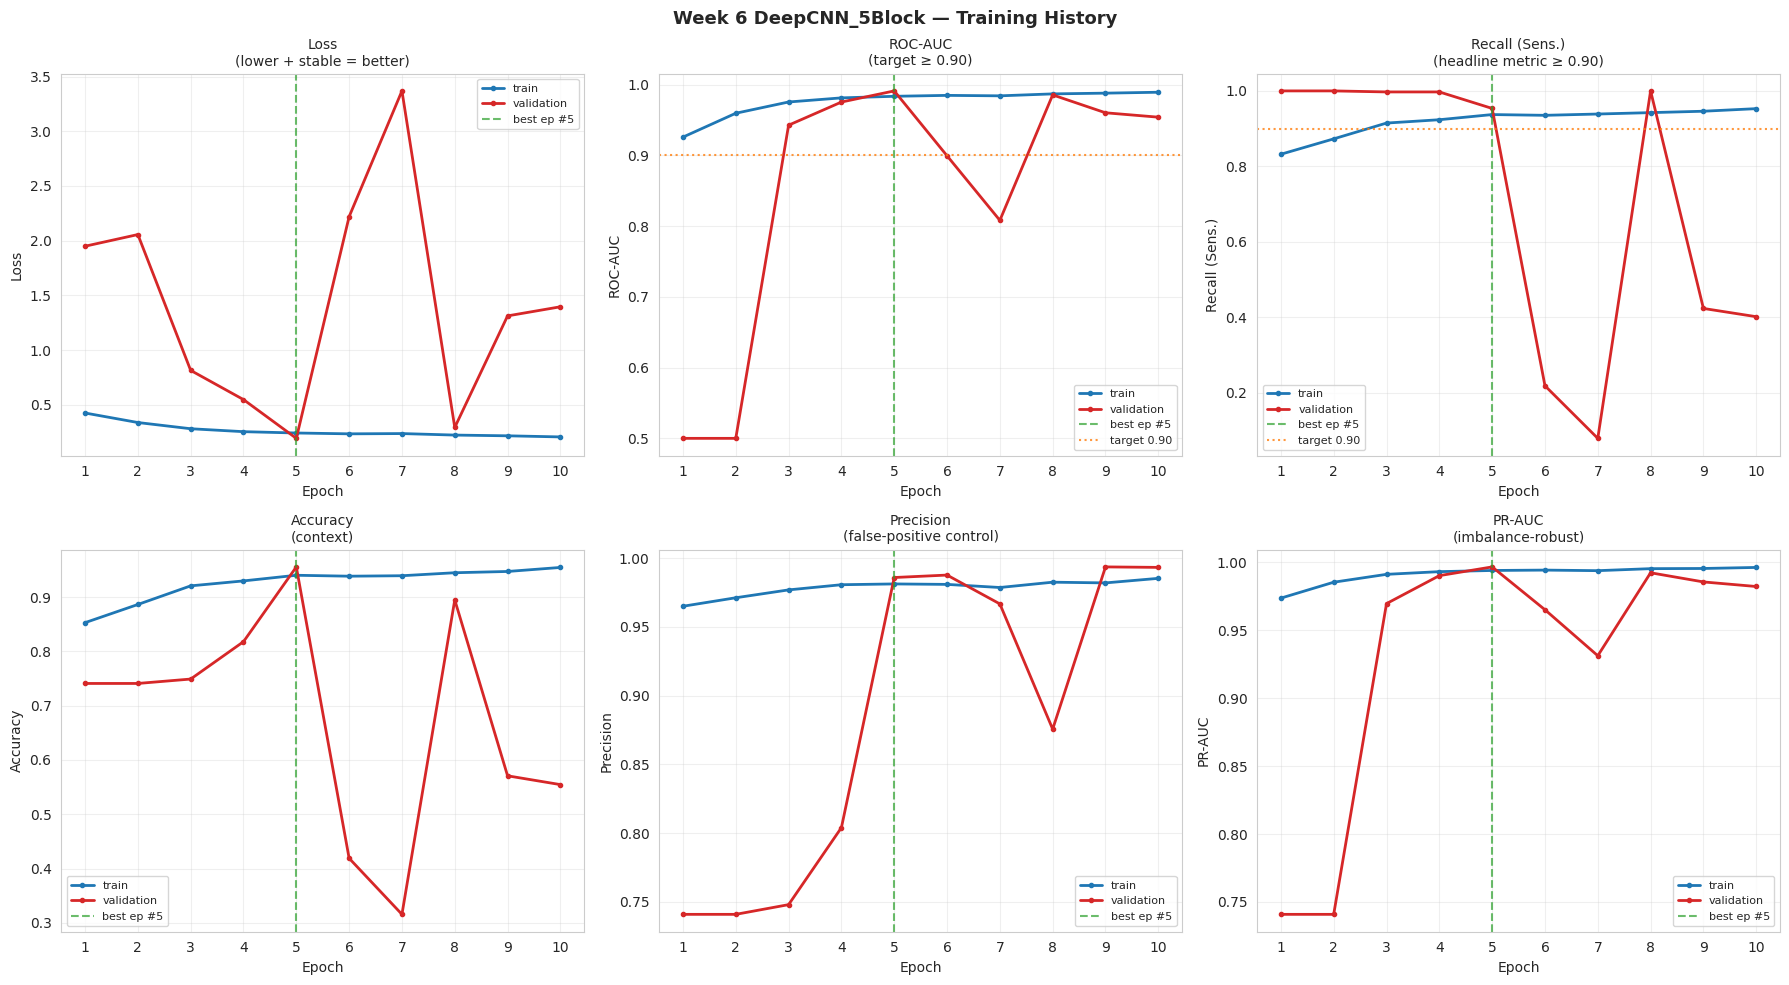

✓ Loaded Week 5 Model B history from Drive.

════════════════════════════════════════════════════════════════════════
  WEEK 5 CHAMPION  vs  WEEK 6 DEEP CNN  —  Benchmarking Matrix
  Green = best value in column   |   ★ = previous champion
════════════════════════════════════════════════════════════════════════



,Model,Architecture,Params,LR Strategy,Best Epoch,val_loss,max_val_loss,val_accuracy,val_precision,val_recall,val_auc,val_pr_auc
0,Week 5 — Model B ★,3 blocks (32→64→128) + GAP + Dense(64),~110K,Static 1e-4 + ReduceLROnPlateau,11,0.3663,1.5596,0.8057,0.7961,0.9918,0.9618,0.9859
1,Week 6 — DeepCNN_5Block,5 blocks (32→64→128→256→512) + GAP + Dense(128),"1,637,345",CosineDecay (1e-4 → 1e-6),5,0.1926,3.3687,0.9555,0.9859,0.9536,0.9910,0.9966



✓ Saved: reports/week06_comparison.csv


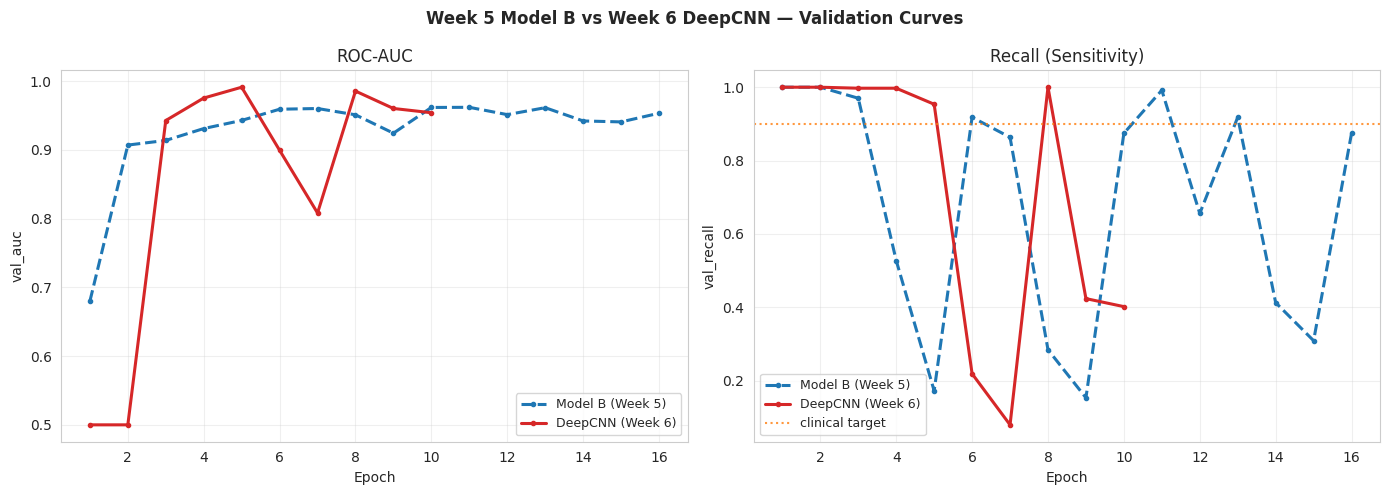

In [9]:
# ============================================================
#  WEEK 6 — CELL 6: LEARNING CURVES + WEEK 5 vs WEEK 6 COMPARISON
# ============================================================

# ── Part A — Learning curves (2×3 grid) ──────────────────────
hist     = w6_history.history
best_idx = int(np.argmax(hist["val_auc"]))
ep_axis  = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Week 6 DeepCNN_5Block — Training History",
             fontsize=13, weight="bold")

panels = [
    ("loss",      "val_loss",      "Loss",          "lower + stable = better"),
    ("auc",       "val_auc",       "ROC-AUC",       "target ≥ 0.90"),
    ("recall",    "val_recall",    "Recall (Sens.)", "headline metric ≥ 0.90"),
    ("accuracy",  "val_accuracy",  "Accuracy",       "context"),
    ("precision", "val_precision", "Precision",      "false-positive control"),
    ("pr_auc",    "val_pr_auc",    "PR-AUC",         "imbalance-robust"),
]
for ax, (tk, vk, title, subtitle) in zip(axes.ravel(), panels):
    ax.plot(ep_axis, hist[tk], label="train",      linewidth=2,
            color="#1f77b4", marker="o", markersize=3)
    ax.plot(ep_axis, hist[vk], label="validation", linewidth=2,
            color="#d62728", marker="o", markersize=3)
    ax.axvline(best_idx + 1, linestyle="--", color="#2ca02c", alpha=0.7,
               label=f"best ep #{best_idx+1}")
    if vk in ("val_recall", "val_auc"):
        ax.axhline(0.90, linestyle=":", color="#ff7f0e", alpha=0.8,
                   label="target 0.90")
    ax.set_title(f"{title}\n({subtitle})", fontsize=10)
    ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig08_deep_cnn_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Part B — Benchmarking matrix ─────────────────────────────
def extract_best(hist_dict, label, arch, params, lr_strategy):
    """Pull every tracked metric at the best-val_auc epoch."""
    best = int(np.argmax(hist_dict["val_auc"]))
    return {
        "Model":         label,
        "Architecture":  arch,
        "Params":        params,
        "LR Strategy":   lr_strategy,
        "Best Epoch":    best + 1,
        "val_loss":      round(hist_dict["val_loss"][best],       4),
        "max_val_loss":  round(max(hist_dict["val_loss"]),        4),
        "val_accuracy":  round(hist_dict["val_accuracy"][best],   4),
        "val_precision": round(hist_dict["val_precision"][best],  4),
        "val_recall":    round(hist_dict["val_recall"][best],     4),
        "val_auc":       round(hist_dict["val_auc"][best],        4),
        "val_pr_auc":    round(hist_dict["val_pr_auc"][best],     4),
    }

# Load Week 5 Model B history
mb_hist_path = HISTORY_DIR / "model_b_history.json"
rows = []

if mb_hist_path.exists():
    with open(mb_hist_path) as f:
        mb_hist = json.load(f)
    rows.append(extract_best(
        mb_hist,
        label       = "Week 5 — Model B ★",
        arch        = "3 blocks (32→64→128) + GAP + Dense(64)",
        params      = "~110K",
        lr_strategy = "Static 1e-4 + ReduceLROnPlateau",
    ))
    print("✓ Loaded Week 5 Model B history from Drive.")
else:
    mb_hist = None
    rows.append({
        "Model":         "Week 5 — Model B ★",
        "Architecture":  "3 blocks (32→64→128) + GAP + Dense(64)",
        "Params":        "~110K",
        "LR Strategy":   "Static 1e-4 + ReduceLROnPlateau",
        "Best Epoch":    12,
        "val_loss":      np.nan,
        "max_val_loss":  np.nan,
        "val_accuracy":  np.nan,
        "val_precision": np.nan,
        "val_recall":    0.9918,
        "val_auc":       0.9831,
        "val_pr_auc":    np.nan,
    })
    print("⚠ model_b_history.json not on Drive — using confirmed Week 5 headline values.")

rows.append(extract_best(
    w6_history.history,
    label       = "Week 6 — DeepCNN_5Block",
    arch        = "5 blocks (32→64→128→256→512) + GAP + Dense(128)",
    params      = f"{deep_cnn.count_params():,}",
    lr_strategy = "CosineDecay (1e-4 → 1e-6)",
))

comparison_df = pd.DataFrame(rows)

# Styled display
HIGHER  = {"val_accuracy", "val_precision", "val_recall", "val_auc", "val_pr_auc"}
LOWER   = {"val_loss", "max_val_loss"}
META    = {"Model", "Architecture", "Params", "LR Strategy", "Best Epoch"}

def style_fn(df):
    styled = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        if col in META: continue
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(vals) < 2: continue
        best = vals.min() if col in LOWER else vals.max()
        for idx in df.index:
            try:
                if float(df.at[idx, col]) == best:
                    styled.at[idx, col] = "background-color:#c6efce; font-weight:bold"
            except (ValueError, TypeError):
                pass
    return styled

print("\n" + "═"*72)
print("  WEEK 5 CHAMPION  vs  WEEK 6 DEEP CNN  —  Benchmarking Matrix")
print("  Green = best value in column   |   ★ = previous champion")
print("═"*72 + "\n")
display(
    comparison_df.style
        .apply(style_fn, axis=None)
        .format(na_rep="—", precision=4)
        .set_properties(**{"text-align": "center"})
)

comparison_df.to_csv(PROJECT_ROOT / "reports" / "week06_comparison.csv", index=False)
print(f"\n✓ Saved: reports/week06_comparison.csv")

# ── Part C — Overlay curves (only if Model B history available) ─────
if mb_hist is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Week 5 Model B vs Week 6 DeepCNN — Validation Curves",
                 fontsize=12, weight="bold")
    for ax, metric, title in zip(axes,
            ["val_auc", "val_recall"],
            ["ROC-AUC", "Recall (Sensitivity)"]):
        ax.plot(range(1, len(mb_hist[metric])+1), mb_hist[metric],
                linewidth=2.2, color="#1f77b4", linestyle="--",
                label="Model B (Week 5)", marker="o", markersize=3)
        ax.plot(range(1, len(hist[metric])+1), hist[metric],
                linewidth=2.2, color="#d62728",
                label="DeepCNN (Week 6)", marker="o", markersize=3)
        if metric == "val_recall":
            ax.axhline(0.90, linestyle=":", color="#ff7f0e",
                       alpha=0.8, label="clinical target")
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(metric)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig09_w5_vs_w6_overlay.png", dpi=150, bbox_inches="tight")
    plt.show()